# Choosing a Backend

LightGP picks the fastest available backend automatically with `Backend.Auto`.
This tutorial shows the available choices, what `Auto` does, and how to force
a specific backend when benchmarking or debugging.

In [1]:
import os
import sys

# Make the locally-built lightgp importable. Real users install via 'pip install lightgp'.
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..", "python")))

import numpy as np
import matplotlib.pyplot as plt
import lightgp as gp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 90})

## Available backends

| Backend | Library | Available on |
|---------|---------|--------------|
| `Backend.CPU` | reference C++ + Accelerate (macOS) / OpenBLAS (Linux) | always |
| `Backend.Metal` | Apple Metal Shading Language compute shaders | macOS builds |
| `Backend.CUDA` | cuBLAS + cuSOLVER + cuFFT + custom kernels | CUDA-enabled builds |
| `Backend.Auto` | resolves at fit time based on problem shape | always |

## Forcing a specific backend

In [2]:
N, D = 1500, 4
X = rng.standard_normal((N, D)).astype(np.float32)
y = (np.sin(X[:, 0]) + 0.1 * rng.standard_normal(N)).astype(np.float32)

for name, backend in [
    ("CPU",   gp.Backend.CPU),
    ("Metal", gp.Backend.Metal),
    ("Auto",  gp.Backend.Auto),
]:
    try:
        m = gp.GPExact(gp.RBF(), backend=backend, noise_var=0.05)
        m.fit(X, y)
        print(f"{name:<6}  fit ok")
    except Exception as e:
        print(f"{name:<6}  not available: {e}")

CPU     fit ok
Metal   fit ok
Auto    fit ok


## Quick wall-time comparison

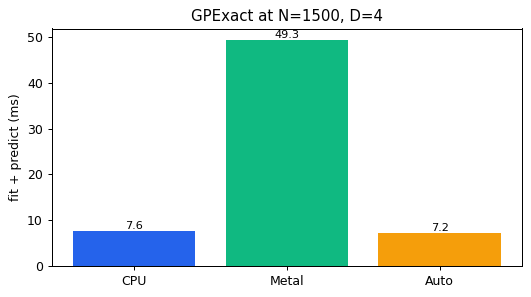

In [3]:
import time
results = {}
for name, backend in [
    ("CPU",   gp.Backend.CPU),
    ("Metal", gp.Backend.Metal),
    ("Auto",  gp.Backend.Auto),
]:
    try:
        m = gp.GPExact(gp.RBF(), backend=backend, noise_var=0.05)
        m.fit(X, y); m.predict(X[:16])   # warmup
        t0 = time.perf_counter()
        m.fit(X, y); m.predict(X[:16])
        results[name] = (time.perf_counter() - t0) * 1000.0
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(6, 3.4))
names = list(results.keys()); vals = list(results.values())
ax.bar(names, vals, color=["#2563EB", "#10B981", "#F59E0B"][: len(names)])
for n, v in zip(names, vals):
    ax.text(n, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("fit + predict (ms)")
ax.set_title(f"GPExact at N={N}, D={D}")
plt.tight_layout(); plt.show()

## How `Backend.Auto` chooses

The dispatch heuristic, derived empirically and baked into
`resolve_auto_backend`:

```text
Solver.SKI                           → CPU (vDSP, on macOS)
Solver.CG, N > 2000                  → Metal (matrix-free matvec)
D ≥ 16 and N ≥ 2000                  → Metal (kernel construction)
otherwise                            → CPU (AMX Cholesky wins)
```

A surprising finding: for moderate-N **dense Cholesky** on Apple Silicon, the
CPU (with its AMX matrix coprocessor) **beats** the integrated Metal GPU.
`Auto` reflects that.

## Cross-platform code

The same Python script runs unchanged on macOS and Linux. With `Backend.Auto`,
LightGP picks the Metal / CUDA / OpenBLAS path that fits the host.